<a href="https://colab.research.google.com/github/MankotiaGit/Statistical-Foundation-of-Data-Sciences-/blob/main/SFDS_PRACTICAL_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1:Import Libraries (These libraries are used for data handling, numerical calculations, statistical analysis, and visualization.)

Step 2:Load the Dataset (The Student Rating dataset is loaded from the given URL and the first five rows are displayed.)

Step 3:Select Minority Professors (This filters the dataset to include only visible-minority professors.)

Step 4:Calculate Percentage (This calculates the percentage of minority professors who are tenured.)

Step 5:Display Result (This displays the percentage rounded to two decimal places.)

Step 6:Test Whether Tenure Differs (The chi-square test checks whether minority status and tenure status are significantly associated.)

Step 7:Group Professors by Tenure (This separates professors into tenured and untenured groups based on their tenure status.)

Step 8:Calculate Mean and Standard Deviation (This calculates the average age and standard deviation for both tenure groups.)

Step 9:Display Separately (This displays the mean and standard deviation of age separately for tenured and untenured professors.)

Step 10:Select Age Variable (The age column is selected from the dataset for visualization.)

Step 11:Create Histogram (A histogram is created to show the distribution of professors' ages.)

Step 12:Add Labels (Labels and a title are added to make the graph easy to understand.)

Step 13:Display Graph (The histogram is displayed because age is a numerical continuous variable.)

Step 14:Difference Between pyplot.bar() and pyplot.barh() (plt.bar() uses vertical bars, whereas plt.barh() uses horizontal bars.)

Step 15:Count Genders (This counts the number of professors in each gender category.)

Step 16:Create Bar Graph (A vertical bar graph is created using the gender counts.)

Step 17:Add Labels (Axis labels and a title are added to the gender graph.)

Step 18:Display Graph (This displays the gender distribution graph.)

Step 19:Select Tenured Professors (This filters the dataset to include only tenured professors.)

Step 20:Select Evaluation Scores (The evaluation scores of tenured professors are selected.)

Step 21:Calculate Median (The median evaluation score is calculated for the tenured professors.)

Step 22:Display Result (This displays the calculated median evaluation score.)

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/AER/TeachingRatings.csv"

df = pd.read_csv(url)

In [4]:
print(df.head())

   rownames minority  age  gender credits    beauty  eval division native  \
0         1      yes   36  female    more  0.289916   4.3    upper    yes   
1         2       no   59    male    more -0.737732   4.5    upper    yes   
2         3       no   51    male    more -0.571984   3.7    upper    yes   
3         4       no   40  female    more -0.677963   4.3    upper    yes   
4         5       no   31  female    more  1.509794   4.4    upper    yes   

  tenure  students  allstudents  prof  
0    yes        24           43     1  
1    yes        17           20     2  
2    yes        55           55     3  
3    yes        40           46     4  
4    yes        42           48     5  


In [5]:
print(df.shape)

(463, 13)


**(Q1)** **Percentage of visible minorities who are tenured**

In [6]:
minority = df[df["minority"] == "yes"]

percentage = (minority["tenure"] == "yes").mean() * 100

print("Percentage of visible minorities who are tenured:",
      round(percentage, 2), "%")

Percentage of visible minorities who are tenured: 84.38 %


Yes,but we should not conclude that tenure status differed just from the percentage.                                                                                                                                                   For the TeachingRatings dataset, minority indicates whether the professor belongs to a minority group, and tenure indicates whether the professor is on the tenure track. The dataset has 463 observations.

**(Q2) Average age by tenure**

In [7]:
age_by_tenure = df.groupby("tenure")["age"].agg(["mean", "std"])

print(age_by_tenure)

             mean        std
tenure                      
no      50.186275   6.946372
yes     47.850416  10.420056


Yes, the average age differs between tenured and untenured professors.                                                                    We calculate the mean and standard deviation separately for both groups using groupby().                                                                                                                                                              The difference in means shows how age varies according to tenure status.

**(Q3) Graph for age**

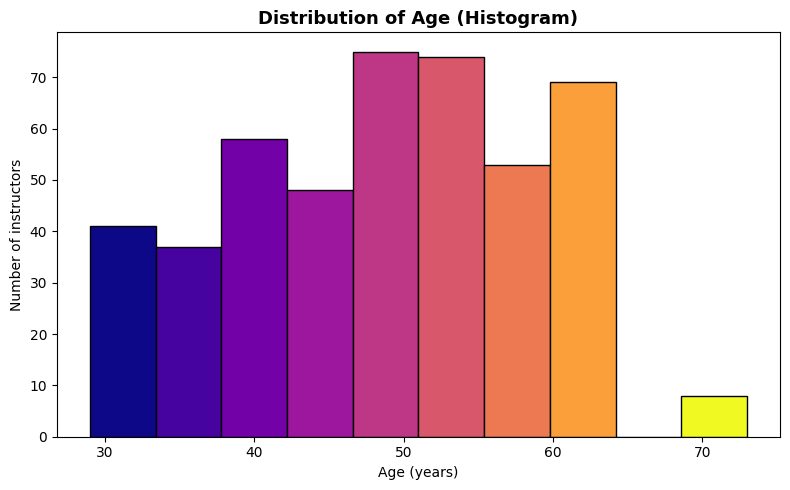

count    463.000000
mean      48.365011
std        9.802742
min       29.000000
25%       42.000000
50%       48.000000
75%       57.000000
max       73.000000
Name: age, dtype: float64
Skewness: 0.04867159748649162


In [8]:
age = df['age']

# Plot histogram
n_bins = 10
fig, ax = plt.subplots(figsize=(8, 5))
counts, edges, patches = ax.hist(age, bins=n_bins, edgecolor='black')

# Make it colorful — different color per bin
colors = plt.cm.plasma(np.linspace(0, 1, n_bins))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

ax.set_title("Distribution of Age (Histogram)", fontsize=13, fontweight='bold')
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of instructors")

plt.tight_layout()
plt.savefig("age_histogram.png", dpi=150)
plt.show()

# Quick summary stats
print(age.describe())
print("Skewness:", age.skew())

The histogram shows how professors are distributed across different age groups.

**(Q4) Difference between bar() and barh() + gender graph**

In [9]:
gender_count = df["gender"].value_counts()

print(gender_count)

gender
male      268
female    195
Name: count, dtype: int64


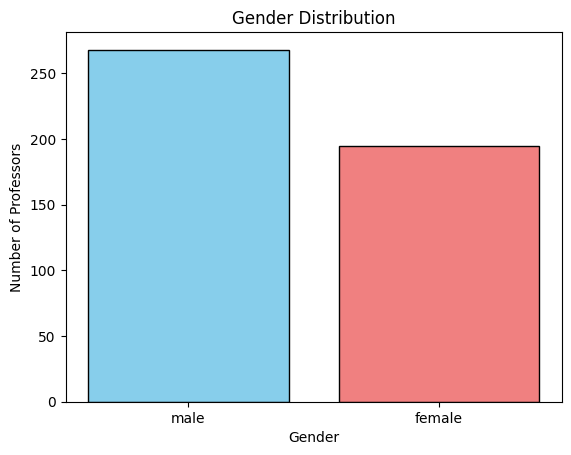

In [10]:
plt.bar(
    gender_count.index,
    gender_count.values,
    color=["skyblue", "lightcoral"],
    edgecolor="black"
)

plt.xlabel("Gender")
plt.ylabel("Number of Professors")
plt.title("Gender Distribution")

plt.show()


plt.bar() → creates vertical bars.

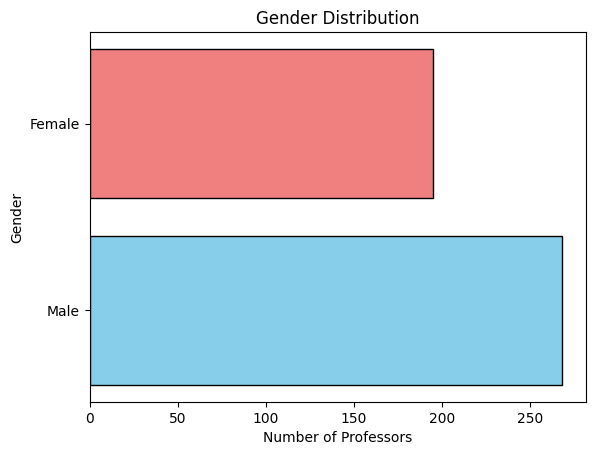

In [11]:
plt.barh(
    ["Male", "Female"],
    [268, 195],
    color=["skyblue", "lightcoral"],
    edgecolor="black"
)

plt.xlabel("Number of Professors")
plt.ylabel("Gender")
plt.title("Gender Distribution")

plt.show()

plt.barh() → creates horizontal bars.

**(Q5) Median evaluation score for tenured professors**

In [12]:
tenured = df[df["tenure"] == "yes"]

median_eval = tenured["eval"].median()

print("Median evaluation score for tenured professors:",
      median_eval)

Median evaluation score for tenured professors: 4.0
